# Assignment 4: Correlation Analysis and Bootstrapping

## Objective

The field of statistics is divided into two major parts: descriptive and inferential. In this assignment, we will cover two important topics in statistics: correlation analysis and bootstrapping, where the former belongs to the descriptive part and the latter belongs to the inferential part. After this assignment, you will be able to answer the following questions:

1. How to visualize the relationship between two variables?  
2. What is Pearson's correlation? How to compute it?
3. What is Spearman's rank correlation? How to compute it?
4. What's the difference between Pearson's correlation and Spearman's rank correlation? 
5. How to estimate a population parameter based on a sample?
6. How to use the bootstrap to quantify the uncertainty of an estimated value?

**Requirements:**
* Use [pandas](https://pandas.pydata.org/) to manipulate data.
* Use [matplotlib](https://matplotlib.org/) or [seaborn](https://seaborn.pydata.org) to make plots.
* Please pay attention to visualization principles. 


The data can be downloaded from [A4-data.zip](A4-data.zip).


## Part 1. Correlation Analysis

As a data scientist, you often face this kind of question: "Are A and B correlated?" For example, 

* Do Canadian Currency and Oil Price move together?
* Do Vancouver Housing Price and US Stock Market have any correlation?
* Are GPA and Gender independent? 

To answer these questions, you need to conduct a correlation analysis. 

Imagine you are a data scientist working at a real-estate company. You download a property_tax_report from this [webpage](https://opendata.vancouver.ca/explore/dataset/property-tax-report/information/?disjunctive.neighbourhood_code). The dataset contains information on properties from BC Assessment (BCA) and City sources in 2019. You can find the schema information of the dataset on the same page. 

You may think that for a newly built house, it tends to have a higher price than the ones built decades ago. In this assignment, your first job is to figure out whether YEAR_BUILT and HOUSE_PRICE are correlated. 

We first load the data as a DataFrame. 

In [2]:
import pandas as pd

df = pd.read_csv("A4-data/property_tax_report_2019.csv")

df['HOUSE_PRICE'] = df.apply(lambda x: (x['CURRENT_LAND_VALUE'] \
                                        +x['CURRENT_IMPROVEMENT_VALUE'])/1000000.0, axis = 1)

df.head()

,PID,LEGAL_TYPE,FOLIO,LAND_COORDINATE,ZONE_NAME,ZONE_CATEGORY,LOT,BLOCK,PLAN,DISTRICT_LOT,...,CURRENT_LAND_VALUE,CURRENT_IMPROVEMENT_VALUE,TAX_ASSESSMENT_YEAR,PREVIOUS_LAND_VALUE,PREVIOUS_IMPROVEMENT_VALUE,YEAR_BUILT,BIG_IMPROVEMENT_YEAR,TAX_LEVY,NEIGHBOURHOOD_CODE,HOUSE_PRICE
0,010-543-490,LAND,638035310000,63803531,RS-1,One Family Dwelling,17,C,VAP7743,538,...,3117000.0,40900.0,2020.0,3663000.0,36100.0,1948.0,1958.0,NaN,1,3.1579
1,010-868-810,LAND,643019250000,64301925,RS-1,One Family Dwelling,3,7,VAP6583,140,...,6007000.0,5943000.0,2020.0,7373000.0,6278000.0,2013.0,2015.0,NaN,1,11.9500
2,007-944-055,LAND,23637870000,2363787,RS-1,One Family Dwelling,7,137,VAP6064,540,...,3400000.0,1417000.0,2020.0,4108000.0,1421000.0,2010.0,2011.0,NaN,1,4.8170
3,007-284-250,LAND,24630040000,2463004,RS-1,One Family Dwelling,E,130,VAP17355,540,...,3991000.0,186000.0,2020.0,4813000.0,189000.0,1980.0,1980.0,NaN,1,4.1770
4,005-264-642,STRATA,24637320005,2463732,CD-1 (123),Comprehensive Development,5,NaN,VAS506,540,...,2670000.0,222000.0,2020.0,3281000.0,241000.0,1978.0,1978.0,NaN,1,2.8920


### Task A. Visualizations

Since the housing price varies a lot by locations, we will only consider the houses whose postcode starts with 'V6A'. Furthermore, we remove the houses that were built before 1900.

In the following, please make two subplots in one row. For the left subplot, it is a scatter plot with X = `YEAR_BUILT` and Y = `HOUSE_PRICE`; for the right subplot, it is a hexbin plot (gridsize = 20) with X = `YEAR_BUILT` and Y = `HOUSE_PRICE`.

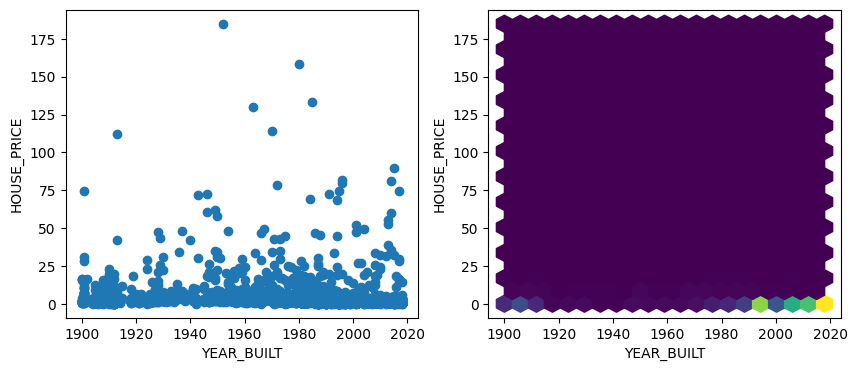

In [5]:
import matplotlib.pyplot as plt  # Import matplotlib for making plots

# --- 1) Filter the data we want to plot ---
# Keep only rows where:
# (1) the postal code starts with "V6A"
# (2) the house was built in 1900 or later
df_v6a = df[
    (df['PROPERTY_POSTAL_CODE'].str.startswith('V6A')) &
    (df['YEAR_BUILT'] >= 1900)
]

# --- 2) Create two subplots in one row (1 row, 2 columns) ---
# fig = the whole figure (the big canvas)
# ax  = an array of axes (plot areas): ax[0] is left, ax[1] is right
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# --- 3) Left plot: Scatter plot ---
# X-axis: YEAR_BUILT (year the house was built)
# Y-axis: HOUSE_PRICE (house price in millions)
# Each point represents one house
ax[0].scatter(df_v6a['YEAR_BUILT'], df_v6a['HOUSE_PRICE'])
ax[0].set_xlabel('YEAR_BUILT')    # Label for the x-axis
ax[0].set_ylabel('HOUSE_PRICE')   # Label for the y-axis

# --- 4) Right plot: Hexbin plot ---
# Hexbin groups points into hexagon bins and shows how many points are in each bin
# This is useful when there are many points overlapping
# gridsize=20 controls how many bins we use (bigger = more detailed, smaller = more coarse)
ax[1].hexbin(df_v6a['YEAR_BUILT'], df_v6a['HOUSE_PRICE'], gridsize=20)
ax[1].set_xlabel('YEAR_BUILT')    # Label for the x-axis
ax[1].set_ylabel('HOUSE_PRICE')   # Label for the y-axis

# --- 5) Display the plots ---
plt.show()

Please write down the **two** most interesting findings that you draw from the plot.

**Findings**
1. Most houses have relatively low house prices, and only a few houses have very high prices. This means the house price distribution is highly uneven, with some expensive outliers.
2. Many houses were built in the early 1900s, fewer houses were built in the middle years, and construction started increasing again after around 1980. The number of houses built appears to be highest close to 2020.

The above plots provide a general impression of the relationship between variables. There are some other visualizations that can provide more insights. One option is to bin one variable and plot percentiles of the other. 


In the following, please make three subplots in a row, where each subplot is a scatter plot with X = YEAR_BUILT and Y = HOUSE_PRICE. 
* The first subplot shows how the 25th percentile of `HOUSE_PRICE` changes over years (X = `YEAR_BUILT`, Y = `25TH_HOUSE_PRICE`); 
* The second subplot shows how the 50th percentile of `HOUSE_PRICE` changes over years (X = `YEAR_BUILT`, Y = `50TH_HOUSE_PRICE`); 
* The third subplot shows how the 75th percentile of `HOUSE_PRICE` changes over years (X = `YEAR_BUILT`, Y = `75TH_HOUSE_PRICE`);  


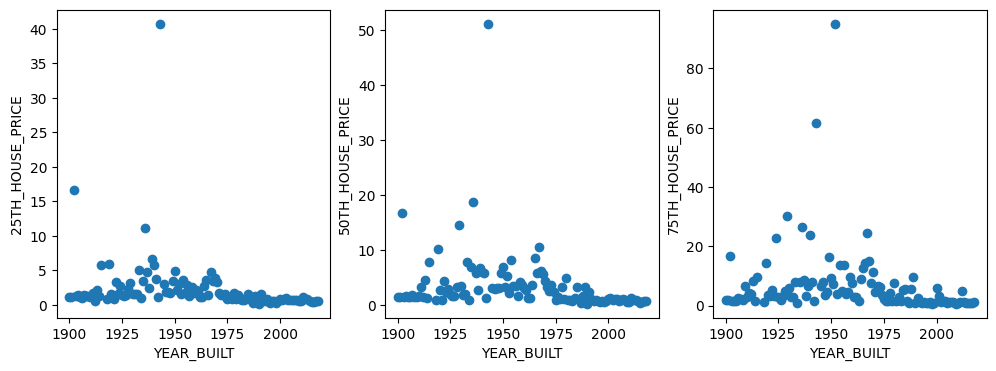

In [6]:
import matplotlib.pyplot as plt

# group by YEAR_BUILT and calculate percentiles
p25 = df_v6a.groupby('YEAR_BUILT')['HOUSE_PRICE'].quantile(0.25)
p50 = df_v6a.groupby('YEAR_BUILT')['HOUSE_PRICE'].quantile(0.50)
p75 = df_v6a.groupby('YEAR_BUILT')['HOUSE_PRICE'].quantile(0.75)

# make subplots
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# 25th percentile
ax[0].scatter(p25.index, p25.values)
ax[0].set_xlabel('YEAR_BUILT')
ax[0].set_ylabel('25TH_HOUSE_PRICE')

# 50th percentile
ax[1].scatter(p50.index, p50.values)
ax[1].set_xlabel('YEAR_BUILT')
ax[1].set_ylabel('50TH_HOUSE_PRICE')

# 75th percentile
ax[2].scatter(p75.index, p75.values)
ax[2].set_xlabel('YEAR_BUILT')
ax[2].set_ylabel('75TH_HOUSE_PRICE')

plt.show()

Please write down the **two** most interesting findings that you draw from the plot.

**Findings**
1. The 25th, 50th, and 75th percentile values vary more for houses built between about 1900 and 1960, showing larger price differences among older properties.
2. After around 1980, the percentile values become lower and more stable, suggesting that house prices for more recently built properties are more consistent in this dataset.

### Task B. Correlation Coefficient

A correlation coefficient is a numerical measure of some type of correlation, meaning a statistical relationship between a pair of variables. 

In the following, please implement `calc_pearson()` and `calc_spearman()`, respectively. Note that you are *NOT* allowed to use [corr](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html) from Pandas or [pearsonr](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html#scipy.stats.pearsonr)/[spearmanr](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html#scipy.stats.spearmanr) from scipy.stats to do this task. In other words, you need to implement the actual algorithms for pearson and spearman.

In [7]:
import numpy as np

def calc_pearson(df, x, y):
    # remove missing values
    data = df[[x, y]].dropna()
    
    X = data[x].values
    Y = data[y].values
    
    # means
    x_mean = np.mean(X)
    y_mean = np.mean(Y)
    
    # Pearson formula
    numerator = np.sum((X - x_mean) * (Y - y_mean))
    denominator = np.sqrt(np.sum((X - x_mean)**2) * np.sum((Y - y_mean)**2))
    
    return numerator / denominator


def calc_spearman(df, x, y):
    # remove missing values
    data = df[[x, y]].dropna()
    
    # convert to ranks
    rx = data[x].rank().values
    ry = data[y].rank().values
    
    # compute Pearson on ranks
    rx_mean = np.mean(rx)
    ry_mean = np.mean(ry)
    
    numerator = np.sum((rx - rx_mean) * (ry - ry_mean))
    denominator = np.sqrt(np.sum((rx - rx_mean)**2) * np.sum((ry - ry_mean)**2))
    
    return numerator / denominator

Then, you can use these two functions to compute the Pearson's correlation as well as Spearman's rank correlation for three pairs of variables: <`25TH_HOUSE_PRICE`, `YEAR_BUILT`>, <`50TH_HOUSE_PRICE`, `YEAR_BUILT`>, and <`75TH_HOUSE_PRICE`, `YEAR_BUILT`>. 

In [10]:
dfcor = df_v6a.groupby('YEAR_BUILT')['HOUSE_PRICE'].quantile([0.25, 0.5, 0.75]).unstack()

dfcor.columns = ['25TH_HOUSE_PRICE', '50TH_HOUSE_PRICE', '75TH_HOUSE_PRICE']
dfcor = dfcor.reset_index()

print(dfcor.head(10))
print()

for TH in ["25TH", "50TH", "75TH"]:
    print(TH+"_HOUSE_PRICE\t pearson=%f\t spearman=%f"  \
          %(calc_pearson(dfcor, "YEAR_BUILT", TH+"_HOUSE_PRICE"), \
            calc_spearman(dfcor, "YEAR_BUILT", TH+"_HOUSE_PRICE")))

   YEAR_BUILT  25TH_HOUSE_PRICE  50TH_HOUSE_PRICE  75TH_HOUSE_PRICE
0      1900.0           1.19000           1.49340          1.869750
1      1901.0           1.12955           1.48850          1.920575
2      1902.0          16.61400          16.61400         16.614000
3      1903.0           1.24615           1.42620          1.506300
4      1904.0           1.45450           1.57920          1.614300
5      1905.0           1.18700           1.46090          1.648250
6      1906.0           0.96450           1.45235          2.410000
7      1907.0           1.44855           1.71800          2.055000
8      1908.0           1.32100           1.47480          1.697000
9      1909.0           1.22175           1.47715          6.650650

25TH_HOUSE_PRICE	 pearson=-0.232917	 spearman=-0.576773
50TH_HOUSE_PRICE	 pearson=-0.238876	 spearman=-0.538693
75TH_HOUSE_PRICE	 pearson=-0.178023	 spearman=-0.446361


Please write down the **two** most interesting findings that you draw from the result.

 

**Findings**
1. Newer build years tend to go with lower percentile house prices. This is shown by the negative Spearman correlations for all three percentiles.
2. The trend is clearer in ranking than in a straight line. Pearson is only slightly negative, but Spearman is much more negative, meaning the relationship is not strongly linear, yet it is consistently decreasing overall.

## Part 2. Bootstrapping

In reality, it is more often than not that you can only collect a sample of the data. Whenever you derive a conclusion from a sample (e.g., Vancouver's housing price has increased by 10% since last year), you should ALWAYS ask yourself: **"CAN I TRUST IT?"**. In other words, you want to know that if the same analysis was conducted on the full data, would the same conclusion be derived? In Part 2, you will learn how to use bootstrapping to answer this question. 

In [15]:
df_sample = pd.read_csv("A4-data/property_tax_report_2019_sample.csv")

df_sample['CURRENT_PRICE'] = df_sample.apply(lambda x: x['CURRENT_LAND_VALUE'] \
                                             +x['CURRENT_IMPROVEMENT_VALUE'], axis = 1)

df_sample['PREVIOUS_PRICE'] = df_sample.apply(lambda x: x['PREVIOUS_LAND_VALUE'] \
                                              +x['PREVIOUS_IMPROVEMENT_VALUE'], axis = 1)

df_sample = df_sample[df_sample['LEGAL_TYPE'] == 'STRATA']

df_sample.head()

,Unnamed: 0,PID,LEGAL_TYPE,FOLIO,LAND_COORDINATE,ZONE_NAME,ZONE_CATEGORY,LOT,BLOCK,PLAN,...,TAX_ASSESSMENT_YEAR,PREVIOUS_LAND_VALUE,PREVIOUS_IMPROVEMENT_VALUE,YEAR_BUILT,BIG_IMPROVEMENT_YEAR,TAX_LEVY,NEIGHBOURHOOD_CODE,HOUSE_PRICE,CURRENT_PRICE,PREVIOUS_PRICE
3,110182,029-083-656,STRATA,280631050040,28063105,C-2C1,Commercial,40,47,EPS1418,...,2020.0,335000.0,139000.0,2013.0,2013.0,NaN,21,0.428,428000.0,474000.0
4,168067,024-593-192,STRATA,309770550012,30977055,CD-1 (351),Comprehensive Development,12,NaN,LMS3991,...,2020.0,342000.0,235000.0,1999.0,1999.0,NaN,24,0.541,541000.0,577000.0
5,108323,025-756-494,STRATA,115573060184,11557306,CD-1 (312),Comprehensive Development,184,NaN,BCS535,...,2020.0,976000.0,298000.0,2003.0,2003.0,NaN,28,1.158,1158000.0,1274000.0
6,59130,030-427-037,STRATA,170825850322,17082585,CD-1 (577),NaN,322,NaN,EPS4185,...,2020.0,687000.0,400000.0,2017.0,2017.0,NaN,12,0.959,959000.0,1087000.0
7,24393,028-609-514,STRATA,650184980026,65018498,C-3A,Commercial,26,NaN,BCS4127,...,2020.0,371000.0,230000.0,2011.0,2011.0,NaN,13,0.590,590000.0,601000.0


### Task 1. Analysis Result Without Bootstrapping

Please compute the median of PREVIOUS_PRICE and CURRENT_PRICE, respectively, and compare them in a bar chart.

Median PREVIOUS_PRICE: 773500.0
Median CURRENT_PRICE: 723000.0


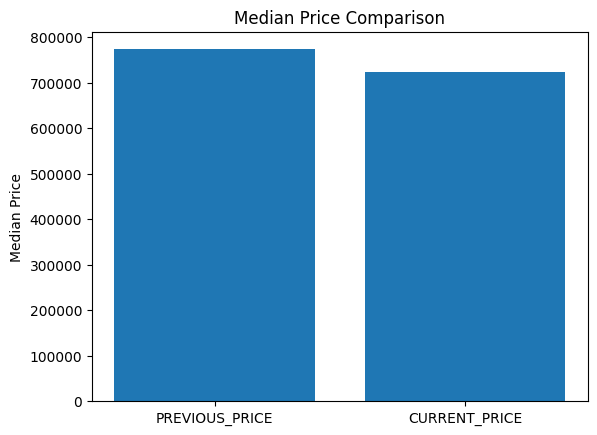

In [16]:
# compute medians
prev_median = df_sample['PREVIOUS_PRICE'].median()
curr_median = df_sample['CURRENT_PRICE'].median()

print("Median PREVIOUS_PRICE:", prev_median)
print("Median CURRENT_PRICE:", curr_median)

# bar chart
plt.bar(['PREVIOUS_PRICE', 'CURRENT_PRICE'], [prev_median, curr_median])
plt.ylabel('Median Price')
plt.title('Median Price Comparison')
plt.show()

### Task 2. Analysis Result With Bootstrapping

From the above chart, we find that the median of PREVIOUS_PRICE is about 0.77 M, and the median of CURRENT_PRICE is about 0.72 M. Since the numbers were obtained from the sample, **"CAN WE TRUST THESE NUMBERS?"**

To address this, implement the bootstrap method to estimate 95% confidence intervals for each median. Use  the provided sample from the dataset as your sample for bootstrapping. This limitation reflects real-world scenarios where only a portion of the data is available for analysis. 

Refer to ["Bootstrap confidence intervals"](https://math.mit.edu/~dav/05.dir/class24-prep-a.pdf) by Jeremy Orloff and Jonathan Bloom for guidance. Section 7 provides a detailed explanation of the algorithm. Once the bootstrap is implemented, add the confidence intervals to the bar chart.


PREVIOUS_PRICE median: 773500.0 95% CI: (736000.0, 806000.0)
CURRENT_PRICE  median: 723000.0 95% CI: (696000.0, 755000.0)


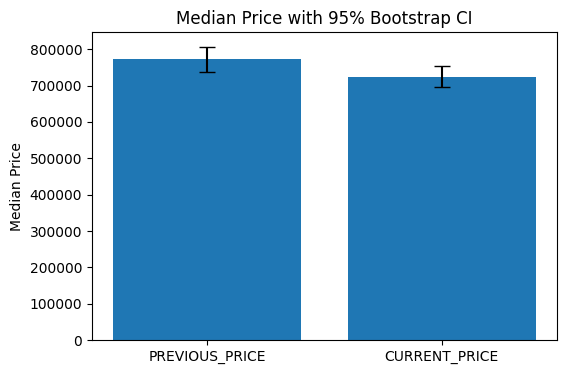

In [17]:
# --- Bootstrap function: 95% CI for median ---
def bootstrap_median_ci(values, B=1000, ci=95, seed=0):
    values = np.array(values)
    values = values[~np.isnan(values)]          # drop NaN
    n = len(values)

    rng = np.random.default_rng(seed)
    meds = []

    for _ in range(B):
        sample = rng.choice(values, size=n, replace=True)  # resample with replacement
        meds.append(np.median(sample))

    meds = np.array(meds)
    alpha = (100 - ci) / 2
    lower = np.percentile(meds, alpha)
    upper = np.percentile(meds, 100 - alpha)
    return np.median(values), lower, upper


# --- Compute medians + 95% CIs ---
prev_med, prev_lo, prev_hi = bootstrap_median_ci(df_sample['PREVIOUS_PRICE'], B=2000, seed=1)
curr_med, curr_lo, curr_hi = bootstrap_median_ci(df_sample['CURRENT_PRICE'],  B=2000, seed=2)

print("PREVIOUS_PRICE median:", prev_med, "95% CI:", (prev_lo, prev_hi))
print("CURRENT_PRICE  median:", curr_med, "95% CI:", (curr_lo, curr_hi))

# --- Bar chart with error bars (CI) ---
labels = ['PREVIOUS_PRICE', 'CURRENT_PRICE']
medians = [prev_med, curr_med]

# error bars need "distance from median"
yerr = [
    [prev_med - prev_lo, curr_med - curr_lo],   # lower errors
    [prev_hi - prev_med, curr_hi - curr_med]    # upper errors
]

plt.figure(figsize=(6,4))
plt.bar(labels, medians, yerr=yerr, capsize=6)
plt.ylabel('Median Price')
plt.title('Median Price with 95% Bootstrap CI')
plt.show()

## Submission

Complete the code in this notebook, and submit it to Canvas.